In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
import os
from scipy.stats import zscore

In [2]:
# set output directory
os.chdir("/ix/djishnu/Aaron_F/GATA2_paper/Results/Fig5c")

In [3]:
# load data
data = pd.read_csv('/ix/djishnu/Aaron_F/GATA2_paper/Data/heatmaps/20250117_deseq2_normalized_RNAseq_counts_exp1_removedSamples.csv', index_col=0)
print(data.shape)

# load degs
gata2_degs = np.loadtxt("/ix/djishnu/Aaron_F/GATA2_paper/Data/heatmaps/WT_vs_GATA2_DEGs_LFC_None_and_padj_0.05.txt", dtype=str).tolist()
print(f"GATA2 DEGs: {len(set(gata2_degs))}")

il33_degs = np.loadtxt("/ix/djishnu/Aaron_F/GATA2_paper/Data/heatmaps/Unstim_vs_IL33_DEGs_LFC_1.5_and_padj_0.05.txt", dtype=str).tolist()
print(f"IL33 DEGs: {len(set(il33_degs))}")


(25239, 14)
GATA2 DEGs: 443
IL33 DEGs: 2038


## combine DEGs

In [4]:
all_degs = list(set(gata2_degs + il33_degs))
print(f"Combined DEGs: {len(set(all_degs))}")

Combined DEGs: 2229


In [5]:
# make data coef specifc
deg_data = data.loc[all_degs]
deg_data

,Unstim_GATA2_0_Exp1_Rep3,IL33_WT_24_Exp1_Rep1,IL33_WT_24_Exp1_Rep2,IL33_GATA2_24_Exp1_Rep3,IL33_GATA2_24_Exp1_Rep4,IL33_GATA2_24_Exp1_Rep5,IL33_GATA2_24_Exp1_Rep6,Unstim_WT_0_Exp1_Rep1,Unstim_WT_0_Exp1_Rep2,Unstim_WT_0_Exp1_Rep3,Unstim_WT_0_Exp1_Rep4,Unstim_WT_0_Exp1_Rep5,Unstim_GATA2_0_Exp1_Rep1,Unstim_GATA2_0_Exp1_Rep2
Arhgef37,1.211014,14.534877,19.239882,30.016783,22.705314,9.700660,15.630038,2.423617,1.669241,2.573426,0.777346,2.913901,6.824144,4.071986
Slc25a35,128.367534,165.334228,156.805039,86.135115,90.821257,82.455610,76.196437,126.028068,116.846900,116.661996,125.152680,112.670837,87.860850,86.869032
Comtd1,388.735646,506.903841,567.576521,537.691931,526.763293,757.864066,517.745018,349.808676,333.013664,325.109534,319.489139,285.562295,324.146827,306.756268
Dnpep,1169.839982,1912.244776,1981.707852,1855.820210,1984.444474,1883.140631,1871.697084,1152.833672,1062.472167,1157.184068,1056.412994,1173.330790,1111.482408,1260.958289
Ogfrl1,1237.656793,883.902217,807.113053,925.299950,798.091799,802.729618,707.259232,1380.653641,1191.838377,1222.377536,1142.698382,1189.842896,1380.183067,1265.030275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Casp4,719.342598,621.365999,836.934870,1310.297813,1363.454126,1253.810310,928.033523,702.040968,490.756979,556.717910,588.450799,657.570319,635.498384,594.509936
Ndufa12,875.563465,1319.040102,1449.725113,1446.025874,1474.710167,1944.982338,1306.085073,840.994992,613.446224,709.407875,755.580154,781.896760,796.718779,864.618331
S100a9,29.064347,15.443307,33.669794,27.406628,45.410629,52.141048,57.635766,7.270850,7.511586,23.160838,10.105496,9.713003,7.677162,14.930615
Sphk1,1.211014,17.260167,24.049853,40.457403,82.874397,72.754950,35.167586,0.807872,3.338483,2.573426,0.777346,5.827802,4.265090,10.858629


In [6]:
# Sort columns alphanumerically
sorted_columns = sorted(deg_data.columns)
print(sorted_columns)

['IL33_GATA2_24_Exp1_Rep3', 'IL33_GATA2_24_Exp1_Rep4', 'IL33_GATA2_24_Exp1_Rep5', 'IL33_GATA2_24_Exp1_Rep6', 'IL33_WT_24_Exp1_Rep1', 'IL33_WT_24_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep1', 'Unstim_GATA2_0_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep1', 'Unstim_WT_0_Exp1_Rep2', 'Unstim_WT_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep4', 'Unstim_WT_0_Exp1_Rep5']


In [7]:
# resort based on prefered order (can use print statement above for ease)
# sorted_columns = ['Unstim_WT_0_Exp1_Rep1', 'Unstim_WT_0_Exp1_Rep2', 'Unstim_WT_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep4', 'Unstim_WT_0_Exp1_Rep5',
#                   'Unstim_GATA2_0_Exp1_Rep1', 'Unstim_GATA2_0_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep3',
#                   'IL33_WT_24_Exp1_Rep1', 'IL33_WT_24_Exp1_Rep2',
#                   'IL33_GATA2_24_Exp1_Rep1', 'IL33_GATA2_24_Exp1_Rep2', 'IL33_GATA2_24_Exp1_Rep3', 'IL33_GATA2_24_Exp1_Rep4', 'IL33_GATA2_24_Exp1_Rep5', 'IL33_GATA2_24_Exp1_Rep6']

# sorted_columns = ['Unstim_WT_0_Exp1_Rep1', 'Unstim_WT_0_Exp1_Rep2', 'Unstim_WT_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep4', 'Unstim_WT_0_Exp1_Rep5',
# 'Unstim_GATA2_0_Exp1_Rep1', 'Unstim_GATA2_0_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep3', 'IL33_WT_24_Exp1_Rep1', 'IL33_WT_24_Exp1_Rep2',
# 'IL33_GATA2_24_Exp1_Rep1', 'IL33_GATA2_24_Exp1_Rep2', 'IL33_GATA2_24_Exp1_Rep3', 'IL33_GATA2_24_Exp1_Rep4', 'IL33_GATA2_24_Exp1_Rep5', 'IL33_GATA2_24_Exp1_Rep6']

# # WT vs GATA2, all samples
# sorted_columns = [
#     'Unstim_WT_0_Exp1_Rep1', 'Unstim_WT_0_Exp1_Rep2', 'Unstim_WT_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep4', 'Unstim_WT_0_Exp1_Rep5',
#     'IL33_WT_24_Exp1_Rep1', 'IL33_WT_24_Exp1_Rep2',
#     'Unstim_GATA2_0_Exp1_Rep1', 'Unstim_GATA2_0_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep3',
#     'IL33_GATA2_24_Exp1_Rep3', 'IL33_GATA2_24_Exp1_Rep4', 'IL33_GATA2_24_Exp1_Rep5', 'IL33_GATA2_24_Exp1_Rep6'
# ]

sorted_columns = [
    'Unstim_WT_0_Exp1_Rep1', 'Unstim_WT_0_Exp1_Rep2', 'Unstim_WT_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep4', 'Unstim_WT_0_Exp1_Rep5',
    'Unstim_GATA2_0_Exp1_Rep1', 'Unstim_GATA2_0_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep3',
    'IL33_WT_24_Exp1_Rep1', 'IL33_WT_24_Exp1_Rep2',
    'IL33_GATA2_24_Exp1_Rep3', 'IL33_GATA2_24_Exp1_Rep4', 'IL33_GATA2_24_Exp1_Rep5', 'IL33_GATA2_24_Exp1_Rep6'
]

# unstim_WT vs Unstim_GATA2:
# sorted_columns = [
#     'Unstim_WT_0_Exp1_Rep1', 'Unstim_WT_0_Exp1_Rep2', 'Unstim_WT_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep4', 'Unstim_WT_0_Exp1_Rep5',
#     'Unstim_GATA2_0_Exp1_Rep1', 'Unstim_GATA2_0_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep3',
# ]

# IL33_WT vs IL33_GATA2:
# sorted_columns = [
#     'IL33_WT_24_Exp1_Rep1', 'IL33_WT_24_Exp1_Rep2',
#     'IL33_GATA2_24_Exp1_Rep3', 'IL33_GATA2_24_Exp1_Rep4', 'IL33_GATA2_24_Exp1_Rep5', 'IL33_GATA2_24_Exp1_Rep6'
# ]

# sorted_columns = ['Unstim_WT_0_Exp2_Rep1', 'Unstim_WT_0_Exp2_Rep2', 'Unstim_WT_0_Exp2_Rep3', 'Unstim_WT_0_Exp2_Rep4', 'Unstim_WT_0_Exp2_Rep5',
#                   'Unstim_GATA2_0_Exp2_Rep1', 'Unstim_GATA2_0_Exp2_Rep2', 'Unstim_GATA2_0_Exp2_Rep3',
#                   'Staph_WT_24_Exp2_Rep1', 'Staph_WT_24_Exp2_Rep2', 'Staph_WT_24_Exp2_Rep3', 'Staph_WT_24_Exp2_Rep4', 'Staph_WT_24_Exp2_Rep5', 'Staph_WT_24_Exp2_Rep6',
#                   'Staph_GATA2_24_Exp2_Rep1', 'Staph_GATA2_24_Exp2_Rep3']

# # Unstim_WT vs Unstim_GATA2:
# sorted_columns = [
#     'Unstim_WT_0_Exp2_Rep1', 'Unstim_WT_0_Exp2_Rep2', 'Unstim_WT_0_Exp2_Rep3', 'Unstim_WT_0_Exp2_Rep4',
#     'Unstim_GATA2_0_Exp2_Rep1', 'Unstim_GATA2_0_Exp2_Rep2', 'Unstim_GATA2_0_Exp2_Rep3'
# ]

# Staph_WT vs Staph_GATA2:
# sorted_columns = [
#     'Staph_WT_24_Exp2_Rep1', 'Staph_WT_24_Exp2_Rep2', 'Staph_WT_24_Exp2_Rep3', 'Staph_WT_24_Exp2_Rep4', 'Staph_WT_24_Exp2_Rep5',
#     'Staph_GATA2_24_Exp2_Rep1', 'Staph_GATA2_24_Exp2_Rep3'
# ]

# sorted_columns = ['Unstim_WT_0_Exp2_Rep1', 'Unstim_WT_0_Exp2_Rep2', 'Unstim_WT_0_Exp2_Rep3', 'Unstim_WT_0_Exp2_Rep4', 'Unstim_WT_0_Exp2_Rep5',
#                   'Staph_WT_24_Exp2_Rep1', 'Staph_WT_24_Exp2_Rep2', 'Staph_WT_24_Exp2_Rep3', 'Staph_WT_24_Exp2_Rep4', 'Staph_WT_24_Exp2_Rep5', 'Staph_WT_24_Exp2_Rep6',
#                   'Unstim_GATA2_0_Exp2_Rep1', 'Unstim_GATA2_0_Exp2_Rep2', 'Unstim_GATA2_0_Exp2_Rep3',
#                   'Staph_GATA2_24_Exp2_Rep1', 'Staph_GATA2_24_Exp2_Rep3']

# sorted_columns = ['Unstim_WT_0_Exp1_Rep1', 'Unstim_WT_0_Exp1_Rep2', 'Unstim_WT_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep4', 'Unstim_WT_0_Exp1_Rep5',
#                   'Unstim_GATA2_0_Exp1_Rep1', 'Unstim_GATA2_0_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep3',
#                   'IL33_WT_24_Exp1_Rep1', 'IL33_WT_24_Exp1_Rep2',
#                   'IL33_GATA2_24_Exp1_Rep1', 'IL33_GATA2_24_Exp1_Rep2', 'IL33_GATA2_24_Exp1_Rep3', 'IL33_GATA2_24_Exp1_Rep4', 'IL33_GATA2_24_Exp1_Rep5', 'IL33_GATA2_24_Exp1_Rep6',
#                   'Unstim_WT_0_Exp2_Rep1', 'Unstim_WT_0_Exp2_Rep2', 'Unstim_WT_0_Exp2_Rep3', 'Unstim_WT_0_Exp2_Rep4', 'Unstim_WT_0_Exp2_Rep5',
#                   'Unstim_GATA2_0_Exp2_Rep1', 'Unstim_GATA2_0_Exp2_Rep2', 'Unstim_GATA2_0_Exp2_Rep3',
#                   'Staph_WT_24_Exp2_Rep1', 'Staph_WT_24_Exp2_Rep2', 'Staph_WT_24_Exp2_Rep3', 'Staph_WT_24_Exp2_Rep4', 'Staph_WT_24_Exp2_Rep5', 'Staph_WT_24_Exp2_Rep6',
#                   'Staph_GATA2_24_Exp2_Rep1', 'Staph_GATA2_24_Exp2_Rep3']

In [8]:
# average replicates:
df = deg_data.copy()
# Extract replicate group names by removing the "RepX" part
df_grouped = df.T
df_grouped.index = df_grouped.index.str.rsplit("_", n=1).str[0]  # Remove last part (RepX)

# Compute the mean for each replicate group
df_avg = df_grouped.groupby(df_grouped.index).mean()

# Reset index and transpose back to original format
df_avg = df_avg.T

df_avg

,IL33_GATA2_24_Exp1,IL33_WT_24_Exp1,Unstim_GATA2_0_Exp1,Unstim_WT_0_Exp1
Arhgef37,19.513199,16.887380,4.035715,2.071506
Slc25a35,83.902105,161.069633,101.032472,119.472096
Comtd1,585.016077,537.240181,339.879580,322.596662
Dnpep,1898.775599,1946.976314,1180.760226,1120.446738
Ogfrl1,808.345150,845.507635,1294.290045,1225.482167
...,...,...,...,...
Casp4,1213.898943,729.150434,649.783639,599.107395
Ndufa12,1542.950863,1384.382608,845.633525,740.265201
S100a9,45.648518,24.556550,17.224041,11.552355
Sphk1,57.813584,20.655010,5.444911,2.664986


In [9]:
df_avg.columns = ["GATA2 IL33", "WT IL33", "GATA2 PBS", "WT PBS"]

In [10]:
df_avg = df_avg.iloc[:,[3, 2, 1, 0]]
df_avg

,WT PBS,GATA2 PBS,WT IL33,GATA2 IL33
Arhgef37,2.071506,4.035715,16.887380,19.513199
Slc25a35,119.472096,101.032472,161.069633,83.902105
Comtd1,322.596662,339.879580,537.240181,585.016077
Dnpep,1120.446738,1180.760226,1946.976314,1898.775599
Ogfrl1,1225.482167,1294.290045,845.507635,808.345150
...,...,...,...,...
Casp4,599.107395,649.783639,729.150434,1213.898943
Ndufa12,740.265201,845.633525,1384.382608,1542.950863
S100a9,11.552355,17.224041,24.556550,45.648518
Sphk1,2.664986,5.444911,20.655010,57.813584


In [11]:
# get rid of Cre related genes Lyz1 and Lyz2
df_avg = df_avg.drop(["Lyz1", "Lyz2"])
df_avg

,WT PBS,GATA2 PBS,WT IL33,GATA2 IL33
Arhgef37,2.071506,4.035715,16.887380,19.513199
Slc25a35,119.472096,101.032472,161.069633,83.902105
Comtd1,322.596662,339.879580,537.240181,585.016077
Dnpep,1120.446738,1180.760226,1946.976314,1898.775599
Ogfrl1,1225.482167,1294.290045,845.507635,808.345150
...,...,...,...,...
Casp4,599.107395,649.783639,729.150434,1213.898943
Ndufa12,740.265201,845.633525,1384.382608,1542.950863
S100a9,11.552355,17.224041,24.556550,45.648518
Sphk1,2.664986,5.444911,20.655010,57.813584


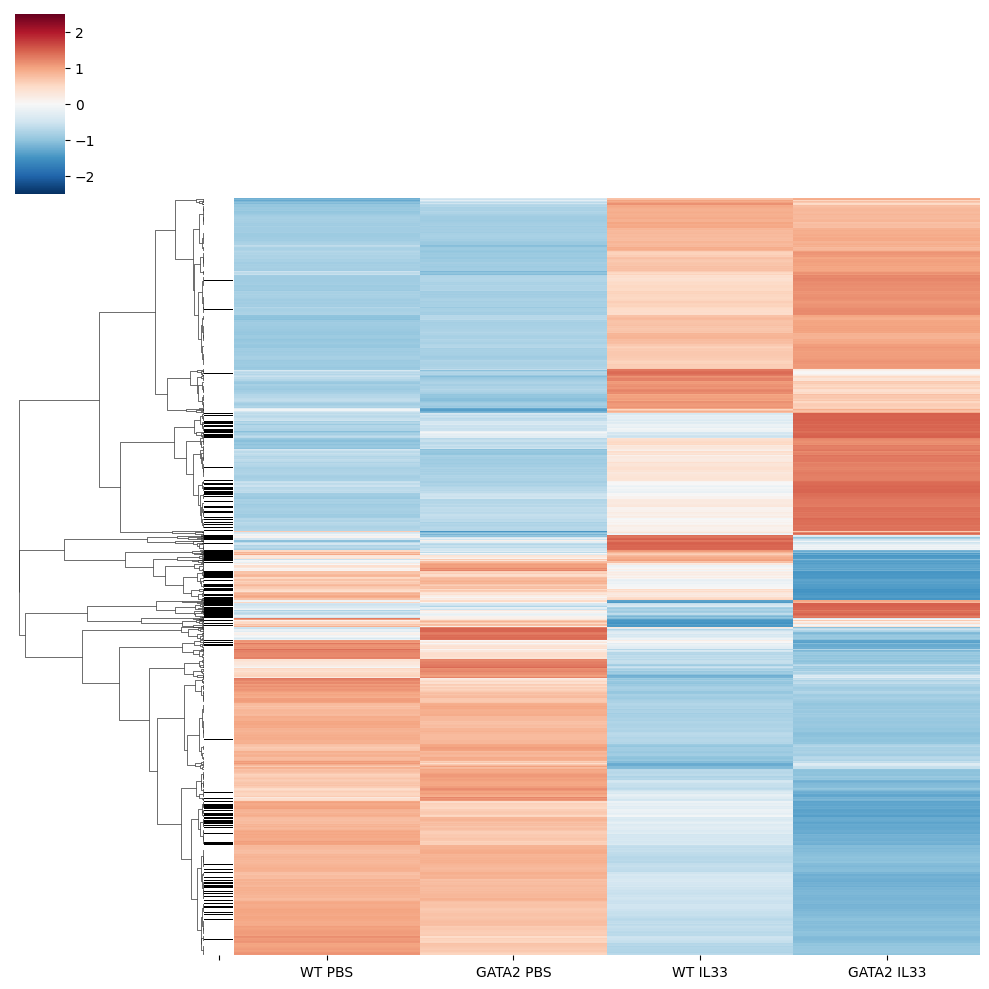

In [12]:
# heatmap
# Create a color vector (black for genes in list, white otherwise)
row_colors = df_avg.index.to_series().apply(lambda x: 'black' if x in gata2_degs else 'white')
c = sns.color_palette("RdBu_r", as_cmap=True)
cluster_heatmap = sns.clustermap(df_avg, metric='correlation', method='complete', cmap=c,
                                 z_score=0, col_cluster=False, row_cluster=True,
                                 vmin=-2.5, vmax=2.5, yticklabels=False, row_colors=row_colors)


# Save and show the heatmap
plt.savefig('GATA2_DEG_Labeled_WT_vs_IL33_DEGs_avgExp_heatmap.pdf', format='pdf')
plt.show()